In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [39]:
#non-linear data-quadractic equation
#quadratic equation=ax^2 + bx + c
x=6*np.random.rand(100,1)-3 #2-D array of 100 rows and 1 column
y=0.5 * x**2 +1.5*x+ 2 + np.random.rand(100,1)
#y=0.5x^2+1.5x+2+outliers



Text(0, 0.5, 'y dataset')

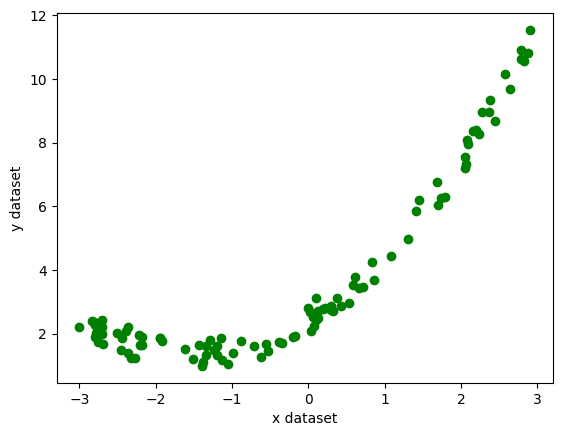

In [40]:

#plot
plt.scatter(x,y,color='green')
plt.xlabel("x dataset")
plt.ylabel("y dataset")

In [41]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


In [42]:
#simple linear regression--learning the relationship between x_train and y_train--learning slope and intercept
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train,y_train)


LinearRegression()

In [43]:
#performance of model on the unseen test data--applying the learn slope and intercept to predict the test data
from sklearn.metrics import r2_score
y_pred=lr.predict(x_test)
r2_score(y_test,y_pred)

0.7664513514675796

Text(0, 0.5, 'y dataset')

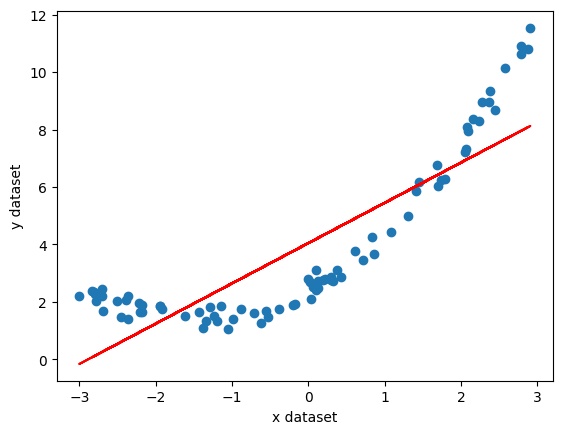

In [44]:
#lets visualize this model--how the best fit line will appear for the training data
plt.plot(x_train,lr.predict(x_train),color='red')
plt.scatter(x_train,y_train)
plt.xlabel("x dataset")
plt.ylabel("y dataset")


In [47]:
#pipeline = first it transforms the data into polynomial form
#           then it appplies linear regression over it
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
def poly_regression(degree):
  x_new=np.linspace(-3,3,200).reshape(200,1)

  poly_features=PolynomialFeatures(degree=degree,include_bias=True) #will create polynomial features according to the degree
  lin_reg=LinearRegression()
  poly_regression=Pipeline([ #objects are passed in the list of tuples
      ("poly_features",poly_features),#transformed X features
       ("Linear_regression",lin_reg) #regression applied on this data
  ])

  poly_regression.fit(x_train,y_train) #polynomial features and fit of linear regression

  #predict y on the basis of new X
  y_pred_new=poly_regression.predict(x_new)

  #plotting prediction line
  plt.plot(x_new,y_pred_new,color='red',label="Degree" + str(degree)+'line')
  plt.plot(x_train,y_train,'b.')
  plt.plot(x_test,y_test,'g.')
  plt.legend(loc='upper left')
  plt.xlabel("x dataset")
  plt.ylabel("y dataset")
  plt.show()



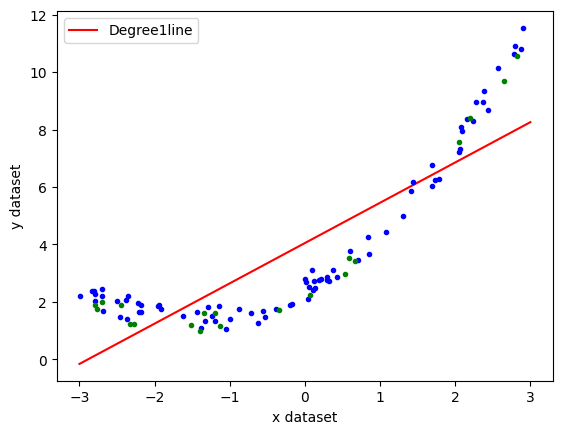

In [57]:
#underfitting
poly_regression(1)

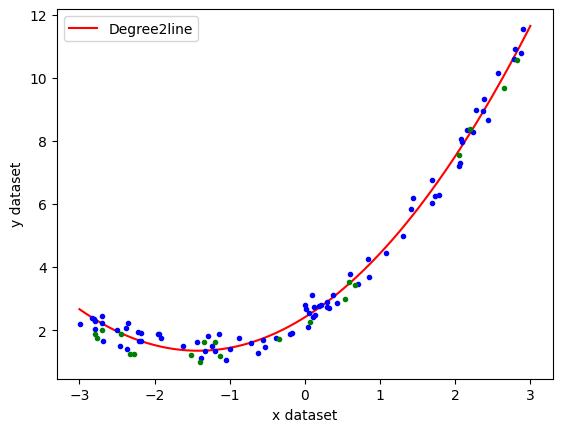

In [55]:
poly_regression(2) #degree=2 model generalises well to the new unseen data

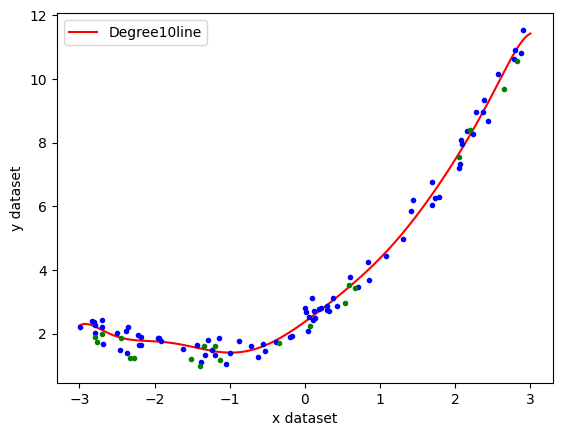

In [56]:
#overfitting
#degree=10
poly_regression(10)